In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
var = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/var_forecast.csv", index_col=0)
var.head()

,Actual_Brent,Forecast_Brent
Date,,
2023-11-01,82.186364,88.166586
2023-12-01,77.540952,87.384469
2024-01-01,79.110000,87.953917
2024-02-01,81.795714,88.786908
2024-03-01,84.961429,89.165762


In [ ]:
prophet = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/prophet_forecast.csv", index_col=0)
prophet.head()

,ds,y,yhat,yhat_lower,yhat_upper,yhat_tuned,yhat_lower_tuned,yhat_upper_tuned,yhat_regressor,yhat_lower_regressor,yhat_upper_regressor
0,2023-11-01,82.186364,63.792321,36.728262,90.493228,74.345743,49.818498,100.069723,78.072301,58.187883,99.140533
1,2023-12-01,77.540952,61.313605,33.509707,91.173977,71.615187,47.798906,95.692667,80.594617,59.610949,102.452598
2,2024-01-01,79.110000,60.952368,34.063280,89.825641,70.824416,47.562675,95.698660,76.734301,55.550290,98.005041
3,2024-02-01,81.795714,62.425103,35.623891,90.142067,72.273700,47.744128,96.352789,85.041527,65.597246,105.038373
4,2024-03-01,84.961429,64.663025,37.235402,90.883275,75.349094,50.902669,98.680771,85.988590,65.991367,108.161776


In [ ]:
vecm = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/vecm_forecast.csv", index_col=0)
vecm.head()

,Brent_price,Forecast_Brent
2023-11-01,82.186364,87.576793
2023-12-01,77.540952,85.820971
2024-01-01,79.110000,85.448802
2024-02-01,81.795714,85.090349
2024-03-01,84.961429,84.174809


In [ ]:
sarimax = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/sarimax_forecast.csv", index_col=0)
sarimax.head()

,Actual,SARIMAX,SARIMAX_lower,SARIMAX_upper
Date,,,,
2023-11-01,82.186364,88.307890,77.261006,99.354773
2023-12-01,77.540952,87.465992,68.868042,106.063942
2024-01-01,79.110000,88.166478,63.404199,112.928758
2024-02-01,81.795714,87.225362,57.279180,117.171543
2024-03-01,84.961429,87.758238,53.315892,122.200584


In [ ]:
garch = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/garch_forecast.csv", index_col=0)
garch.head()

,actual_returns,garch_returns_forecast,garch_volatility,garch_variance,actual_price,garch_price_forecast,garch_price_lower,garch_price_upper
date,,,,,,,,
2023-11-01,-7.905947,0.273603,7.784216,60.594024,82.186364,89.191425,75.305718,103.077131
2023-12-01,-5.818318,-0.553735,8.346214,69.659283,77.540952,88.698905,73.892905,103.504906
2024-01-01,2.003307,-0.213101,7.370155,54.319185,79.110000,88.510088,75.463427,101.556750
2024-02-01,3.338556,1.391918,6.496361,42.202709,81.795714,89.750690,78.089632,101.411748
2024-03-01,3.797252,1.680281,6.264540,39.244459,84.961429,91.271495,79.836017,102.706973


In [ ]:
bsts = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/bsts_forecast.csv", index_col=0)
bsts.head()

,date,actual,bsts_forecast,bsts_forecast_lower,bsts_forecast_upper
0,2023-11-01,82.186364,85.855082,74.201490,97.508675
1,2023-12-01,77.540952,84.856282,65.890798,103.821766
2,2024-01-01,79.110000,84.969337,60.077420,109.861253
3,2024-02-01,81.795714,88.517914,58.503375,118.532454
4,2024-03-01,84.961429,89.023185,54.650702,123.395668


In [ ]:
state_space = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/state_space_predictions.csv", index_col=0)
state_space.head()

,actual,predicted,model
date,,,
2023-11-01,82.186364,86.842862,State Space (SARIMAX)
2023-12-01,77.540952,87.045311,State Space (SARIMAX)
2024-01-01,79.110000,86.392770,State Space (SARIMAX)
2024-02-01,81.795714,86.690634,State Space (SARIMAX)
2024-03-01,84.961429,86.596690,State Space (SARIMAX)


In [ ]:
full_forecast = pd.DataFrame(
    {
        "Date": var.index,
        "Actual_Brent_Price": var["Actual_Brent"].values,
        "ARIMAX": sarimax["SARIMAX"].values,
        "GARCH": garch["garch_price_forecast"].values,
        "VAR": var["Forecast_Brent"].values,
        "Prophet_Tuned": prophet["yhat_tuned"].values,
        "Prophet_Tuned_Regressor": prophet["yhat_regressor"].values,
        "BSTS": bsts["bsts_forecast"].values,
        "State_Space": state_space["predicted"].values,
        "VECM": vecm["Forecast_Brent"].values
    }
)

In [ ]:
full_forecast = full_forecast.set_index('Date').sort_index()

In [ ]:
full_forecast

,Actual_Brent_Price,ARIMAX,GARCH,VAR,Prophet_Tuned,Prophet_Tuned_Regressor,BSTS,State_Space,VECM
Date,,,,,,,,,
2023-11-01,82.186364,88.307890,89.191425,88.166586,74.345743,78.072301,85.855082,86.842862,87.576793
2023-12-01,77.540952,87.465992,88.698905,87.384469,71.615187,80.594617,84.856282,87.045311,85.820971
2024-01-01,79.110000,88.166478,88.510088,87.953917,70.824416,76.734301,84.969337,86.392770,85.448802
2024-02-01,81.795714,87.225362,89.750690,88.786908,72.273700,85.041527,88.517914,86.690634,85.090349
2024-03-01,84.961429,87.758238,91.271495,89.165762,75.349094,85.988590,89.023185,86.596690,84.174809
2024-04-01,88.974545,87.763859,92.920654,89.417259,75.525476,81.602462,88.762607,86.183206,83.326874
2024-05-01,83.053913,87.176170,94.780775,89.663883,77.737519,84.909868,89.493189,86.795945,82.602293
2024-06-01,82.917500,87.699882,94.389836,89.841636,79.121041,85.248095,90.567305,86.998694,81.862825
2024-07-01,84.048696,87.855537,95.272000,90.059591,79.934811,84.336636,90.656160,86.846945,81.228456


In [ ]:
final_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/final_df.csv", index_col=0)

In [ ]:
train = final_df['Brent_price'][:250].sort_index()
train

,Brent_price
2003-01-01,30.808696
2003-02-01,32.662500
2003-03-01,30.168095
2003-04-01,25.035000
2003-05-01,25.714545
...,...
2023-06-01,74.975000
2023-07-01,80.109048
2023-08-01,85.168261
2023-09-01,92.673333


In [ ]:
# --- Clean legend names ---
model_names = {
    "ARIMAX": "ARIMAX",
    "GARCH": "GARCH",
    "VAR": "VAR",
    "Prophet_Tuned": "Prophet (Tuned)",
    "Prophet_Tuned_Regressor": "Prophet + Regressor",
    "BSTS": "BSTS",
    "State_Space": "State Space Model",
    "VECM": "VECM"
}

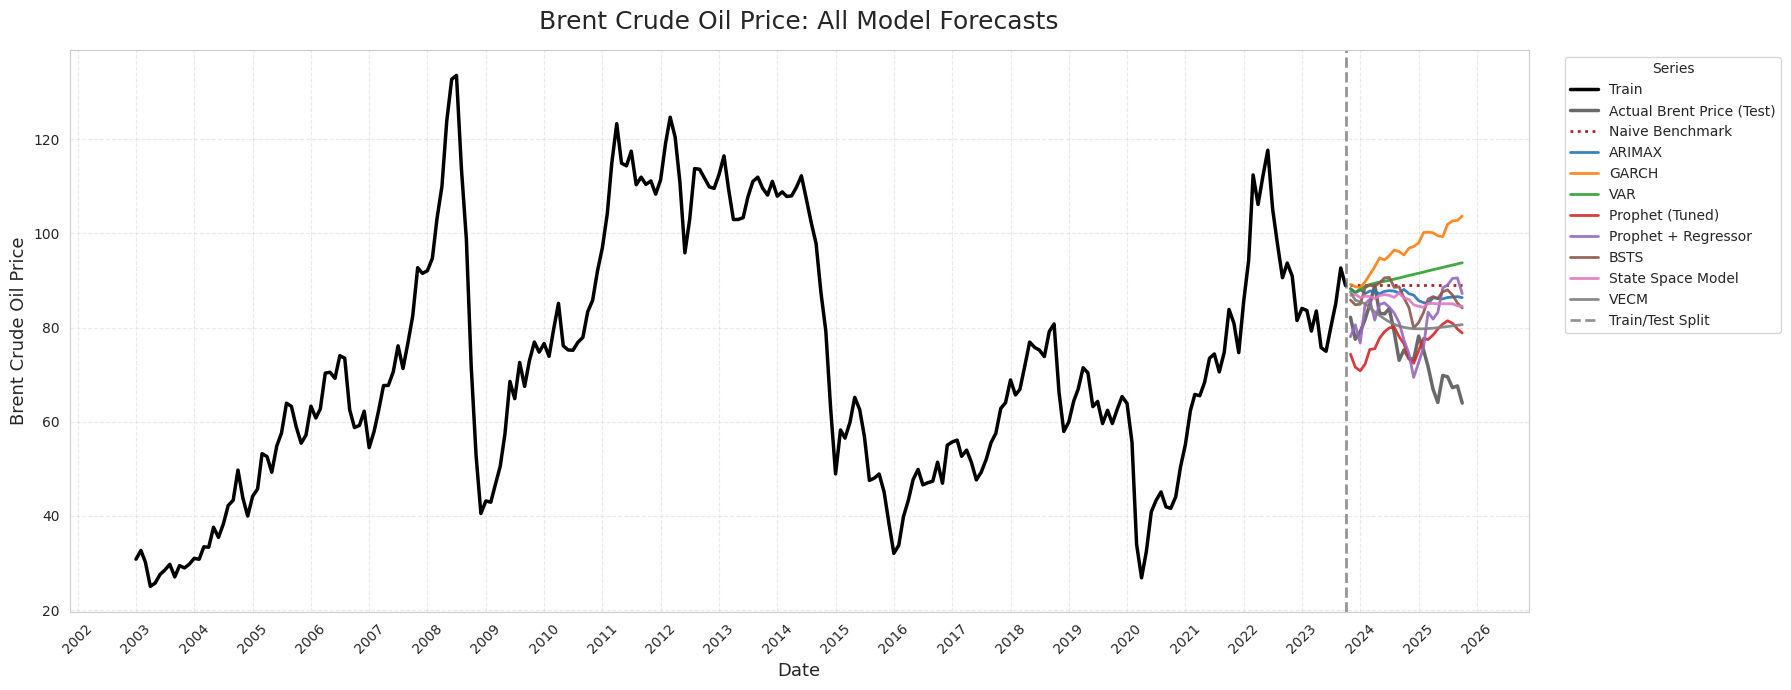

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- Styling ---
sns.set_style("whitegrid")
plt.figure(figsize=(18, 7))

palette = sns.color_palette("tab10", 8)

# --- Ensure datetime index ---
train.index = pd.to_datetime(train.index)
full_forecast.index = pd.to_datetime(full_forecast.index)

# --- Plot training data ---
plt.plot(
    train,
    label="Train",
    linewidth=2.5,
    color="black"
)

# --- Plot actual test values ---
plt.plot(
    full_forecast.index,
    full_forecast["Actual_Brent_Price"],
    label="Actual Brent Price (Test)",
    linewidth=2.5,
    color="dimgray"
)

# --- Naive benchmark (last observed value) ---
naive_forecast = pd.Series(
    train.iloc[-1],
    index=full_forecast.index
)

plt.plot(
    full_forecast.index,
    naive_forecast,
    label="Naive Benchmark",
    linewidth=2,
    linestyle=":",
    color="firebrick"
)

# --- Forecast columns ---
forecast_cols = [
    "ARIMAX",
    "GARCH",
    "VAR",
    "Prophet_Tuned",
    "Prophet_Tuned_Regressor",
    "BSTS",
    "State_Space",
    "VECM"
]

# --- Plot forecasts ---
for i, col in enumerate(forecast_cols):
    plt.plot(
        full_forecast.index,
        full_forecast[col],
        label=model_names[col],   # use clean name
        linewidth=2,
        alpha=0.9,
        color=palette[i]
    )

# --- Vertical line where train ends ---
train_end = train.index[-1]

plt.axvline(
    x=train_end,
    color="dimgray",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Train/Test Split"
)

# --- Formatting ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title(
    "Brent Crude Oil Price: All Model Forecasts",
    fontsize=18,
    pad=15
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Brent Crude Oil Price", fontsize=13)

plt.xticks(rotation=45)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    title="Series"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

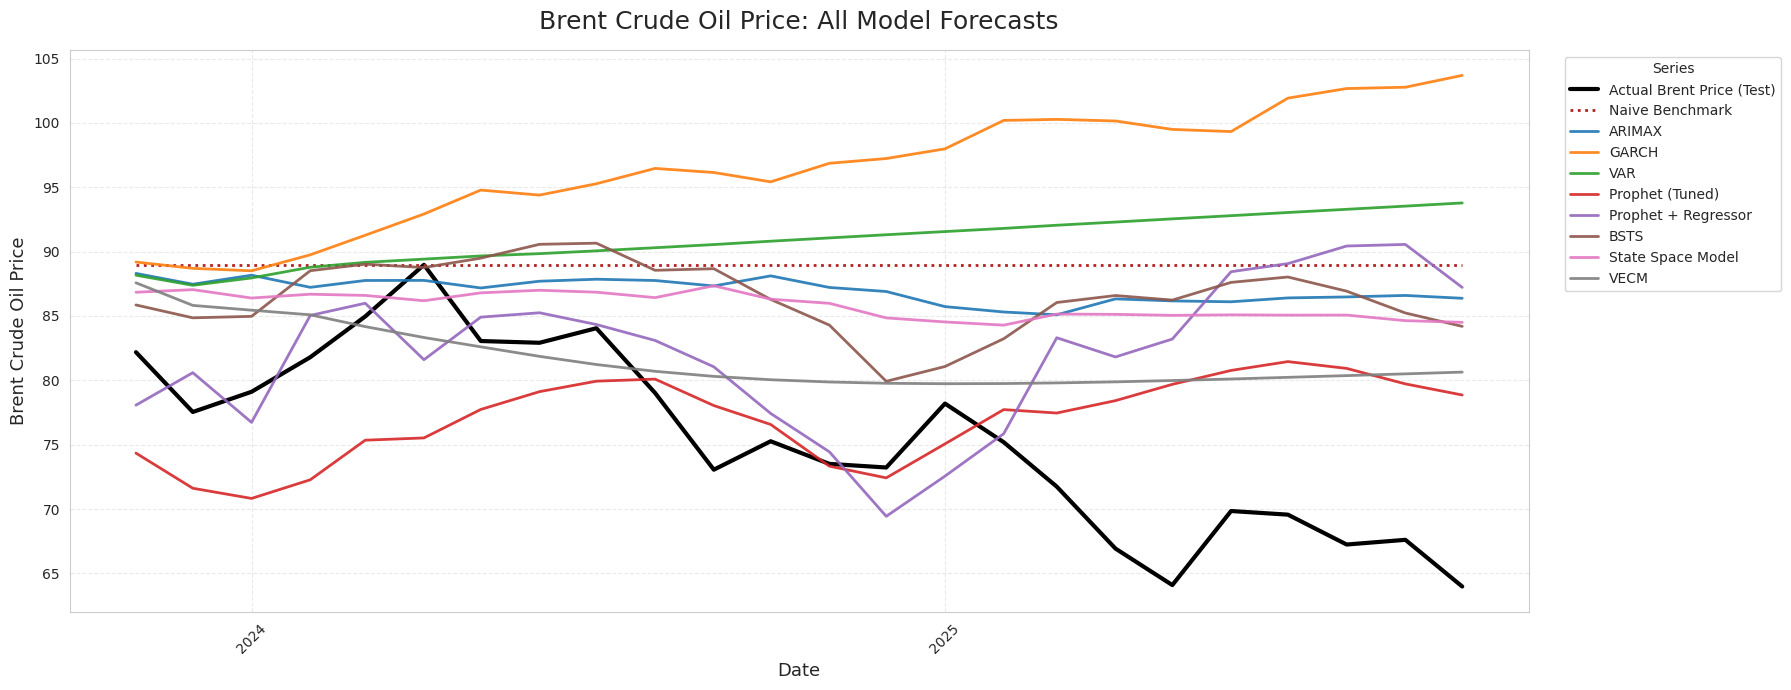

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- Styling ---
sns.set_style("whitegrid")
plt.figure(figsize=(18, 7))

palette = sns.color_palette("tab10", 8)

# --- Ensure datetime index ---
train.index = pd.to_datetime(train.index)
full_forecast.index = pd.to_datetime(full_forecast.index)

# --- Plot actual test values ---
plt.plot(
    full_forecast.index,
    full_forecast["Actual_Brent_Price"],
    label="Actual Brent Price (Test)",
    linewidth=3,
    color="black"
)

# --- Naive benchmark (last observed value) ---
naive_forecast = pd.Series(
    train.iloc[-1],
    index=full_forecast.index
)

plt.plot(
    full_forecast.index,
    naive_forecast,
    label="Naive Benchmark",
    linewidth=2,
    linestyle=":",
    color="firebrick"
)

# --- Forecast columns ---
forecast_cols = [
    "ARIMAX",
    "GARCH",
    "VAR",
    "Prophet_Tuned",
    "Prophet_Tuned_Regressor",
    "BSTS",
    "State_Space",
    "VECM"
]

# --- Plot forecasts ---
for i, col in enumerate(forecast_cols):
    plt.plot(
        full_forecast.index,
        full_forecast[col],
        label=model_names[col],   # use clean name
        linewidth=2,
        alpha=0.9,
        color=palette[i]
    )


# --- Formatting ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title(
    "Brent Crude Oil Price: All Model Forecasts",
    fontsize=18,
    pad=15
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Brent Crude Oil Price", fontsize=13)

plt.xticks(rotation=45)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    title="Series"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Actual values ---
y_true = full_forecast["Actual_Brent_Price"]

# --- Forecast columns ---
forecast_cols = [
    "ARIMAX",
    "GARCH",
    "VAR",
    "Prophet_Tuned",
    "Prophet_Tuned_Regressor",
    "BSTS",
    "State_Space",
    "VECM"
]

# --- Error functions ---
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

# --- Seasonal period (monthly data) ---
m = 12

# --- Seasonal naive scaling error for MASE ---
seasonal_naive_error = np.mean(
    np.abs(train[m:] - train.shift(m)[m:])
)

def mase(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)) / seasonal_naive_error

# --- Compute metrics ---
results = []

for col in forecast_cols:

    y_pred = full_forecast[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Model": col,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred)
    })

metrics_df = pd.DataFrame(results).set_index("Model")

# Round for readability
metrics_df = metrics_df.round(3)

# Sort by RMSE (optional)
metrics_df = metrics_df.sort_values("RMSE")

metrics_df

,MAE,MSE,RMSE,MAPE (%),sMAPE (%),MASE
Model,,,,,,
VECM,6.970,70.640,8.405,9.824,9.157,0.346
Prophet_Tuned,7.424,77.395,8.797,10.165,9.818,0.368
Prophet_Tuned_Regressor,8.498,137.110,11.709,12.163,10.934,0.422
State_Space,10.514,145.164,12.048,14.751,13.396,0.522
BSTS,10.956,160.041,12.651,15.350,13.864,0.544
ARIMAX,11.528,171.330,13.089,16.147,14.562,0.572
VAR,15.337,306.305,17.502,21.503,18.771,0.761
GARCH,20.930,554.704,23.552,29.224,24.530,1.039


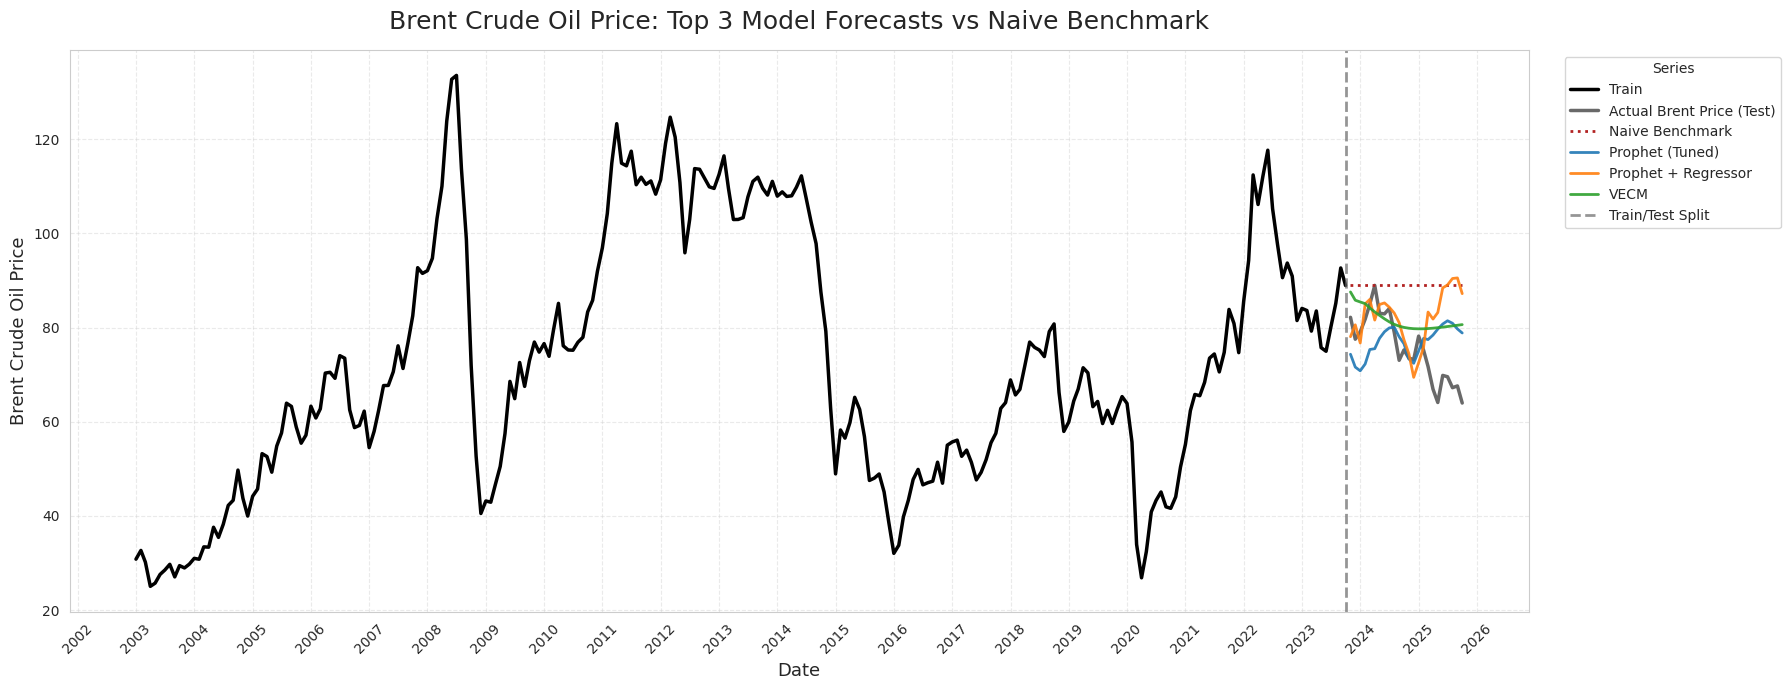

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- Styling ---
sns.set_style("whitegrid")
plt.figure(figsize=(18, 7))

palette = sns.color_palette("tab10", 8)

# --- Ensure datetime index ---
train.index = pd.to_datetime(train.index)
full_forecast.index = pd.to_datetime(full_forecast.index)

# --- Plot training data ---
plt.plot(
    train,
    label="Train",
    linewidth=2.5,
    color="black"
)

# --- Plot actual test values ---
plt.plot(
    full_forecast.index,
    full_forecast["Actual_Brent_Price"],
    label="Actual Brent Price (Test)",
    linewidth=2.5,
    color="dimgray"
)

# --- Naive benchmark (last observed value) ---
naive_forecast = pd.Series(
    train.iloc[-1],
    index=full_forecast.index
)

plt.plot(
    full_forecast.index,
    naive_forecast,
    label="Naive Benchmark",
    linewidth=2,
    linestyle=":",
    color="firebrick"
)

# --- Forecast columns ---
forecast_cols = [
    "Prophet_Tuned",
    "Prophet_Tuned_Regressor",
    "VECM"
]

# --- Plot forecasts ---
for i, col in enumerate(forecast_cols):
    plt.plot(
        full_forecast.index,
        full_forecast[col],
        label=model_names[col],
        linewidth=2,
        alpha=0.9,
        color=palette[i]
    )

# --- Vertical line where train ends ---
train_end = train.index[-1]

plt.axvline(
    x=train_end,
    color="dimgray",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Train/Test Split"
)

# --- Formatting ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title(
    "Brent Crude Oil Price: Top 3 Model Forecasts vs Naive Benchmark",
    fontsize=18,
    pad=15
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Brent Crude Oil Price", fontsize=13)

plt.xticks(rotation=45)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    title="Series"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()